In [1]:
# Database Connection and Table Verification
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

db_path = "../data/predictive_maintenance.db"
if not os.path.exists(db_path):
  db_path = "predictive_maintenance.db"

conn = sqlite3.connect(db_path)
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print(tables)

Empty DataFrame
Columns: [name]
Index: []


In [2]:
# Check Existing Database Files and Tables
import os
import sqlite3

for root, dirs, files in os.walk(".."):
  for file in files:
    if file.endswith(".db") or file.endswith(".sqlite"):
      full_path = os.path.join(root, file)
      print(f"Found Database: {full_path}")
      try:
        conn = sqlite3.connect(full_path)
        tables = pd.read_sql(
            "SELECT name FROM sqlite_master WHERE type='table';", conn
        )
        print(f"Tables in {file}:", tables["name"].tolist())
        conn.close()
      except Exception as e:
        print(f"Error reading {file}: {e}")

Found Database: ..\data\ai4i2020.db
Tables in ai4i2020.db: ['sqlite_sequence', 'machines', 'sensor_readings', 'failure_events']
Found Database: ..\notebooks\predictive_maintenance.db
Tables in predictive_maintenance.db: []


In [4]:
# Inspect Table Schemas and Column Names
import sqlite3
import pandas as pd

db_path = "../data/ai4i2020.db"
conn = sqlite3.connect(db_path)

for table in ["machines", "sensor_readings", "failure_events"]:
  cols = pd.read_sql(f"PRAGMA table_info({table});", conn)
  print(f"--- Columns in {table} ---")
  print(cols[["name", "type"]])
  print("\n")

conn.close()

--- Columns in machines ---
             name     type
0      product_id     TEXT
1            type     TEXT
2       first_udi  INTEGER
3        last_udi  INTEGER
4   reading_count  INTEGER
5  total_failures  INTEGER


--- Columns in sensor_readings ---
                    name     type
0                    udi  INTEGER
1             product_id     TEXT
2                   type     TEXT
3             air_temp_k     REAL
4         process_temp_k     REAL
5   rotational_speed_rpm  INTEGER
6              torque_nm     REAL
7          tool_wear_min  INTEGER
8        machine_failure  INTEGER
9                    twf  INTEGER
10                   hdf  INTEGER
11                   pwf  INTEGER
12                   osf  INTEGER
13                   rnf  INTEGER


--- Columns in failure_events ---
                   name     type
0              event_id  INTEGER
1                   udi  INTEGER
2            product_id     TEXT
3          failure_type     TEXT
4            air_temp_k     REAL
5 

In [5]:
# Extract Cleaned Data from Sensor Readings Table
import sqlite3
import pandas as pd

db_path = "../data/ai4i2020.db"
conn = sqlite3.connect(db_path)

# Query sensor_readings directly
query = "SELECT * FROM sensor_readings;"
df = pd.read_sql(query, conn)
conn.close()

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   udi                   10000 non-null  int64  
 1   product_id            10000 non-null  object 
 2   type                  10000 non-null  object 
 3   air_temp_k            10000 non-null  float64
 4   process_temp_k        10000 non-null  float64
 5   rotational_speed_rpm  10000 non-null  int64  
 6   torque_nm             10000 non-null  float64
 7   tool_wear_min         10000 non-null  int64  
 8   machine_failure       10000 non-null  int64  
 9   twf                   10000 non-null  int64  
 10  hdf                   10000 non-null  int64  
 11  pwf                   10000 non-null  int64  
 12  osf                   10000 non-null  int64  
 13  rnf                   10000 non-null  int64  
 14  temp_diff_k           10000 non-null  float64
 15  power_kw            

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12092\2795035111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="machine_failure", data=df, palette="Set2")


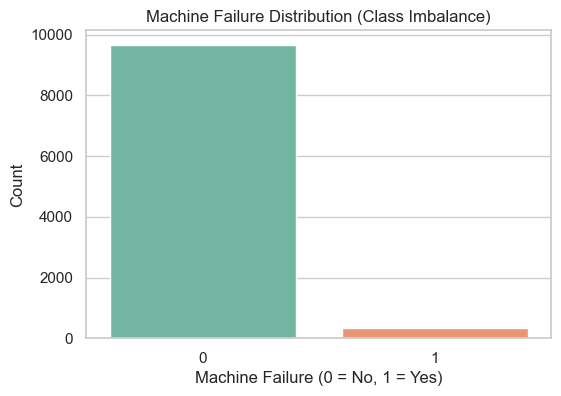

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12092\2795035111.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12092\2795035111.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12092\2795035111.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12092\2795035111.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

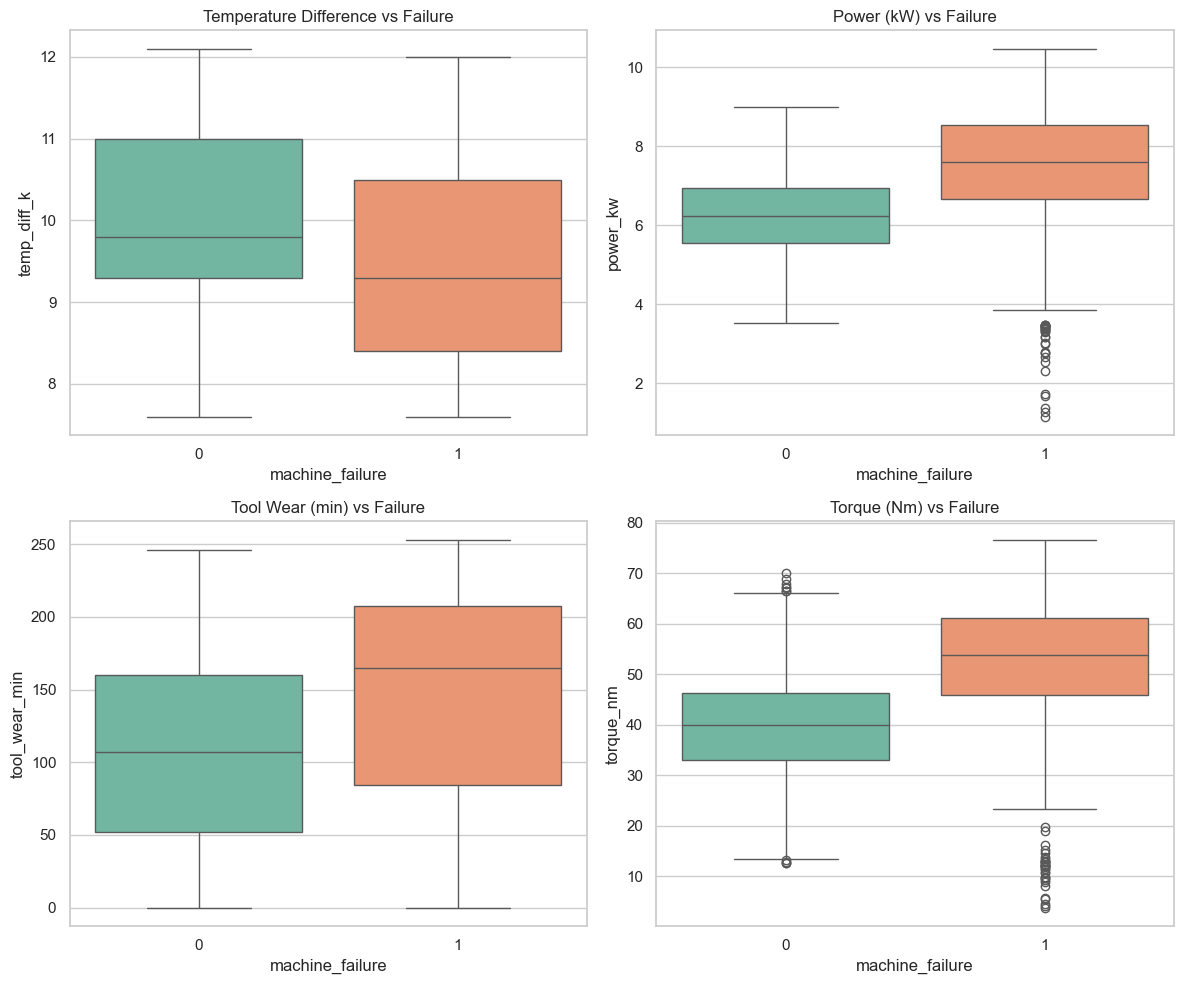

Leakage Columns Detected: ['twf', 'hdf', 'pwf', 'osf', 'rnf']


In [6]:
# Exploratory Data Analysis Plots and Leakage Check
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../reports/figures", exist_ok=True)

# 1. Target Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x="machine_failure", data=df, palette="Set2")
plt.title("Machine Failure Distribution (Class Imbalance)")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("../reports/figures/target_distribution.png", bbox_inches="tight")
plt.show()

# 2. Key Sensor Distributions by Failure Status
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(
    x="machine_failure", y="temp_diff_k", data=df, ax=axes[0, 0], palette="Set2"
)
axes[0, 0].set_title("Temperature Difference vs Failure")

sns.boxplot(
    x="machine_failure", y="power_kw", data=df, ax=axes[0, 1], palette="Set2"
)
axes[0, 1].set_title("Power (kW) vs Failure")

sns.boxplot(
    x="machine_failure",
    y="tool_wear_min",
    data=df,
    ax=axes[1, 0],
    palette="Set2",
)
axes[1, 0].set_title("Tool Wear (min) vs Failure")

sns.boxplot(
    x="machine_failure", y="torque_nm", data=df, ax=axes[1, 1], palette="Set2"
)
axes[1, 1].set_title("Torque (Nm) vs Failure")

plt.tight_layout()
plt.savefig(
    "../reports/figures/sensor_features_vs_failure.png", bbox_inches="tight"
)
plt.show()

# 3. Data Leakage Verification
leakage_cols = ["twf", "hdf", "pwf", "osf", "rnf"]
print("Leakage Columns Detected:", [c for c in leakage_cols if c in df.columns])

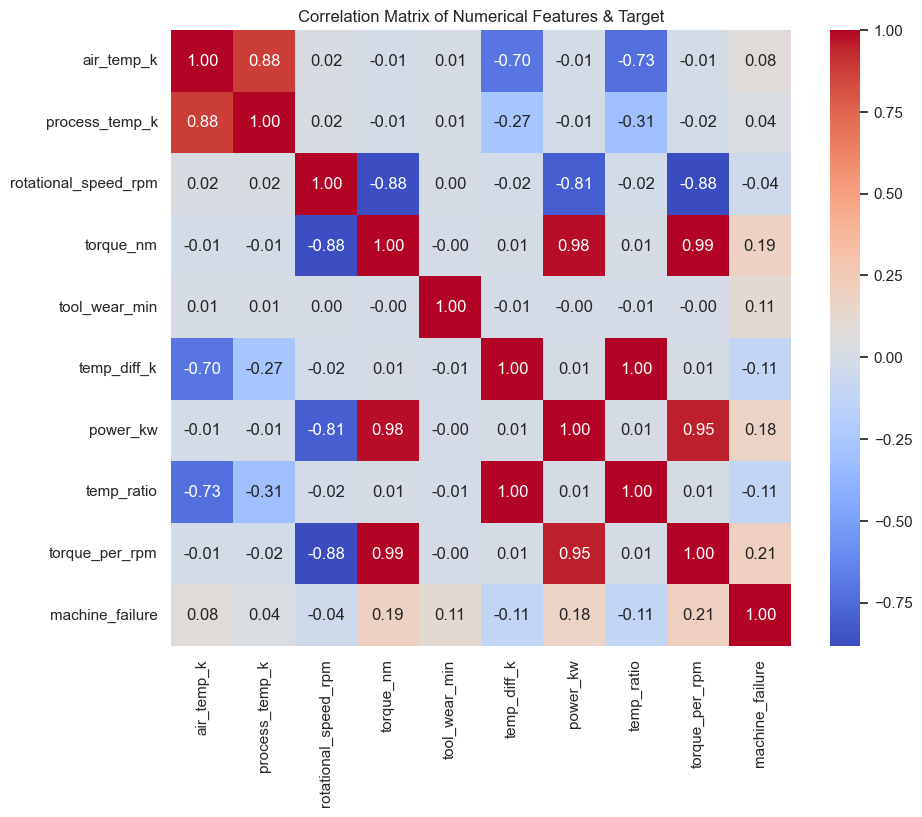

In [7]:
# Correlation Heatmap and Feature Analysis
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temp_diff_k",
    "power_kw",
    "temp_ratio",
    "torque_per_rpm",
    "machine_failure",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features & Target")
plt.savefig("../reports/figures/correlation_matrix.png", bbox_inches="tight")
plt.show()